# 01 - Dataset Exploration & Properties
## CASIA-Iris-Thousand Project

### Main Purpose:
Inspect the CASIA dataset hierarchy, subjects, classes, image counts, image properties, and visualize sample eyes.

---


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sys.path.append(os.path.abspath(".."))
from src.dataset import get_dataset_root, load_dataset_metadata, load_image_as_grayscale
from src.preprocessing import compute_image_quality_metrics

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


### 1. Dataset Hierarchy & Metadata Summary

In [2]:
dataset_root = get_dataset_root()
print(f"Dataset root path: {dataset_root}")

df_meta = load_dataset_metadata(dataset_root)
print(f"Total images found: {len(df_meta):,}")
print(f"Total distinct subjects: {df_meta['subject_id'].nunique()}")
print(f"Total eye identity classes: {df_meta['identity'].nunique()}")

df_meta.head(10)


Dataset root path: c:\Users\Mridul\OneDrive\Desktop\Iris_Recognition_Project\CASIA-Iris-Thousand\CASIA-Iris-Thousand
Total images found: 20,000
Total distinct subjects: 1000
Total eye identity classes: 2000


,subject_id,eye,identity,image_index,filename,file_path
0,000,L,000_L,0,S5000L00.jpg,c:\Users\Mridul\OneDrive\Desktop\Iris_Recognit...
1,000,L,000_L,1,S5000L01.jpg,c:\Users\Mridul\OneDrive\Desktop\Iris_Recognit...
2,000,L,000_L,2,S5000L02.jpg,c:\Users\Mridul\OneDrive\Desktop\Iris_Recognit...
3,000,L,000_L,3,S5000L03.jpg,c:\Users\Mridul\OneDrive\Desktop\Iris_Recognit...
4,000,L,000_L,4,S5000L04.jpg,c:\Users\Mridul\OneDrive\Desktop\Iris_Recognit...
5,000,L,000_L,5,S5000L05.jpg,c:\Users\Mridul\OneDrive\Desktop\Iris_Recognit...
6,000,L,000_L,6,S5000L06.jpg,c:\Users\Mridul\OneDrive\Desktop\Iris_Recognit...
7,000,L,000_L,7,S5000L07.jpg,c:\Users\Mridul\OneDrive\Desktop\Iris_Recognit...
8,000,L,000_L,8,S5000L08.jpg,c:\Users\Mridul\OneDrive\Desktop\Iris_Recognit...
9,000,L,000_L,9,S5000L09.jpg,c:\Users\Mridul\OneDrive\Desktop\Iris_Recognit...


### 2. Distribution: Eye Side and Samples per Subject

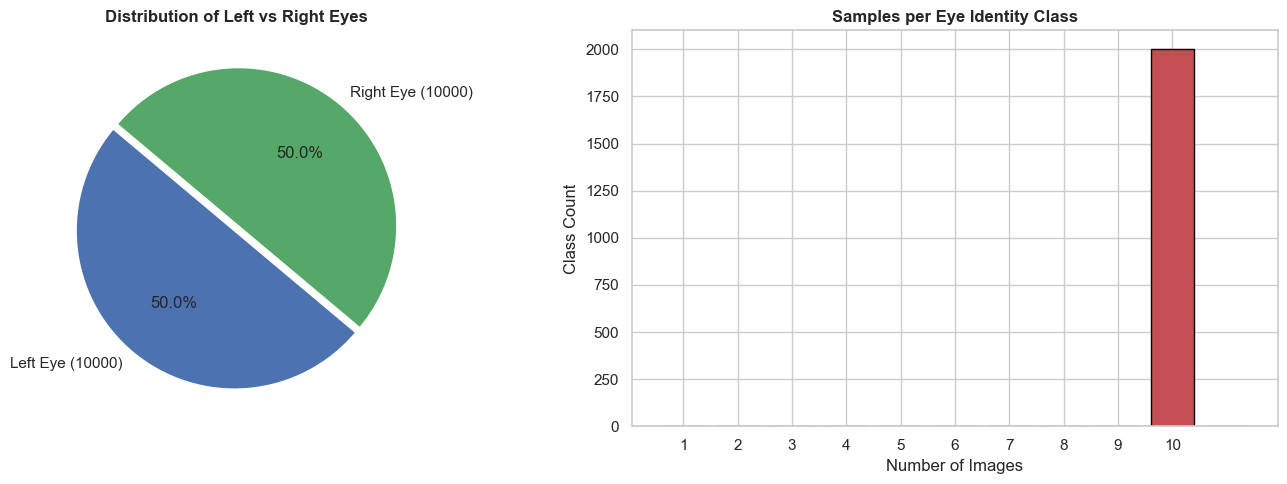

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Eye side breakdown
eye_counts = df_meta['eye'].value_counts()
axes[0].pie(eye_counts, labels=[f"Left Eye ({eye_counts['L']})", f"Right Eye ({eye_counts['R']})"],
            autopct='%1.1f%%', colors=['#4C72B0', '#55A868'], startangle=140, explode=(0.02, 0.02))
axes[0].set_title("Distribution of Left vs Right Eyes", fontweight="bold")

# Distribution of images per identity
img_counts = df_meta.groupby('identity')['image_index'].count()
axes[1].hist(img_counts, bins=np.arange(0.5, 12.5, 1), rwidth=0.8, color='#C44E52', edgecolor='black')
axes[1].set_title("Samples per Eye Identity Class", fontweight="bold")
axes[1].set_xlabel("Number of Images")
axes[1].set_ylabel("Class Count")
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()


### 3. Image Properties & Visual Sample Grids

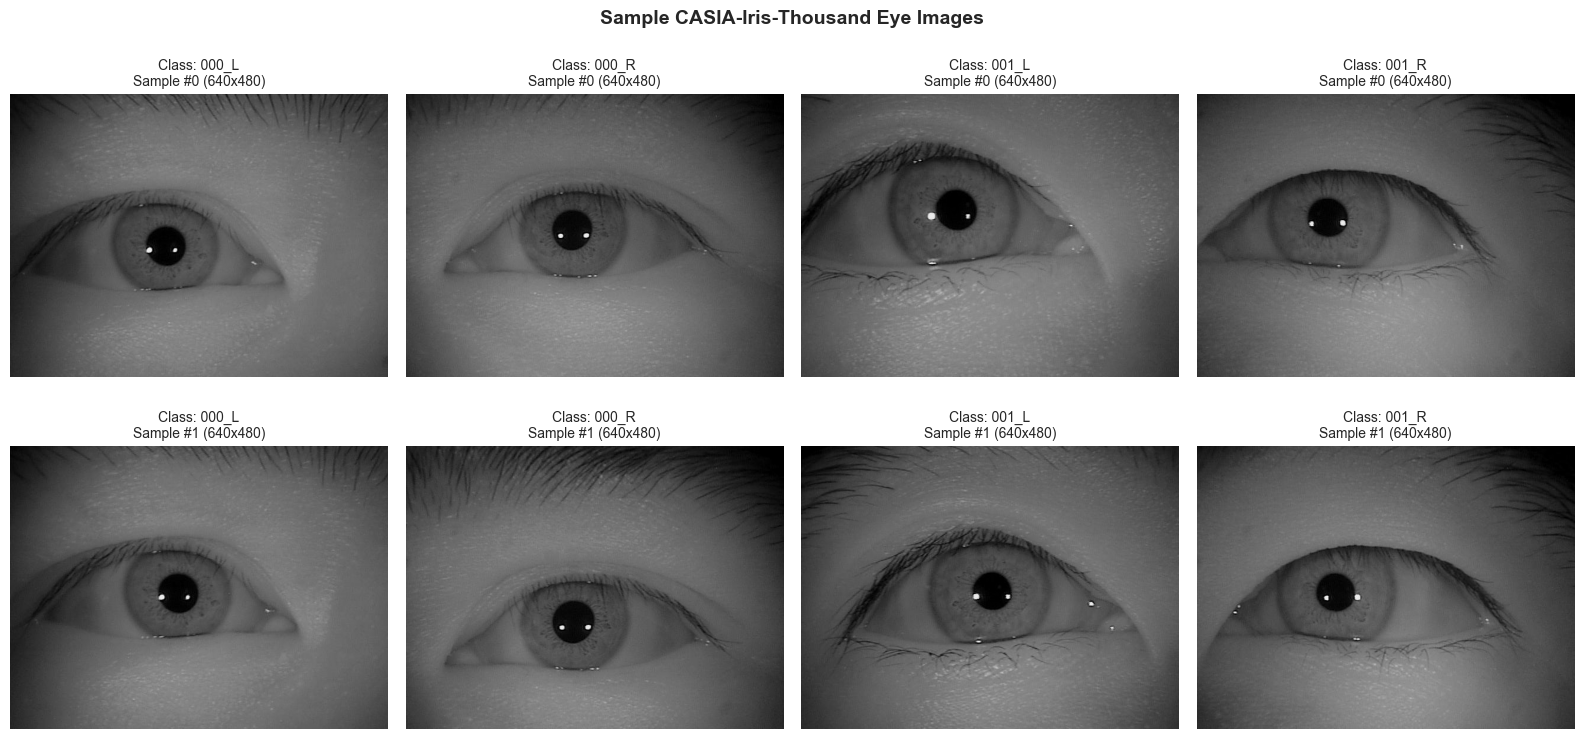

In [4]:
sample_ids = df_meta['identity'].unique()[:4]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col, ident in enumerate(sample_ids):
    paths = df_meta[df_meta['identity'] == ident]['file_path'].values
    for row in range(2):
        img = load_image_as_grayscale(paths[row])
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(f"Class: {ident}\nSample #{row} ({img.shape[1]}x{img.shape[0]})", fontsize=10)
        axes[row, col].axis('off')

plt.suptitle("Sample CASIA-Iris-Thousand Eye Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 4. Quality Metric Profiling

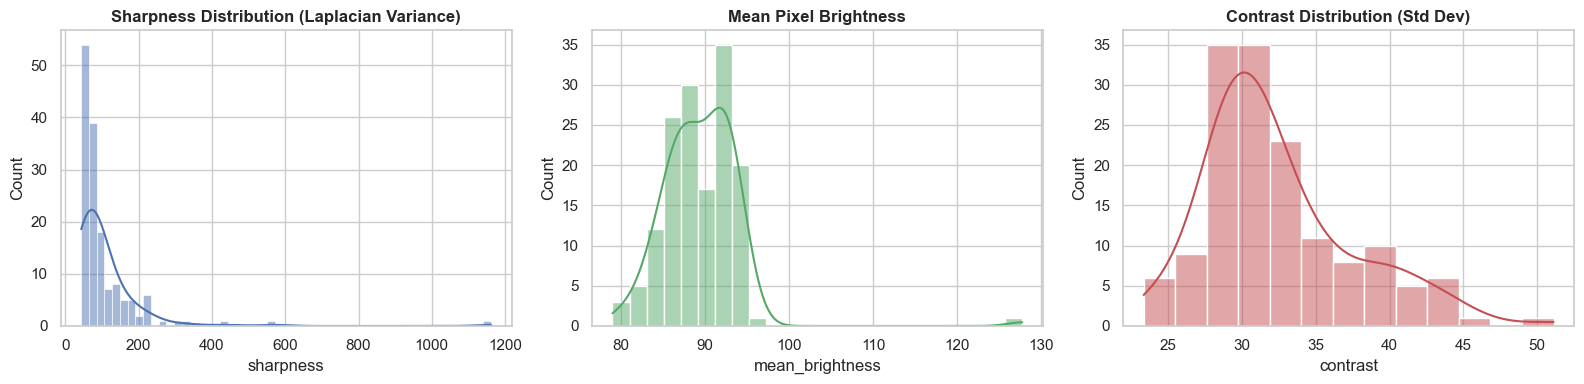

,sharpness,mean_brightness,contrast,reflection_percentage,darkness_percentage
count,150.00,150.00,150.00,150.00,150.00
mean,106.08,89.46,32.39,0.01,2.57
std,112.77,4.78,5.10,0.01,1.86
min,43.04,78.98,23.35,0.00,0.07
25%,56.99,86.67,28.89,0.00,1.25
50%,76.00,89.12,31.06,0.00,2.04
75%,113.08,92.18,34.76,0.01,3.26
max,1161.91,127.77,51.10,0.04,10.21


In [5]:
# Fast quality profiling on random subset of 150 images
sample_df = df_meta.sample(n=min(150, len(df_meta)), random_state=42)

quality_data = [compute_image_quality_metrics(load_image_as_grayscale(p)) for p in sample_df['file_path']]
df_q = pd.DataFrame(quality_data)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df_q['sharpness'], kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title("Sharpness Distribution (Laplacian Variance)", fontweight="bold")

sns.histplot(df_q['mean_brightness'], kde=True, ax=axes[1], color='#55A868')
axes[1].set_title("Mean Pixel Brightness", fontweight="bold")

sns.histplot(df_q['contrast'], kde=True, ax=axes[2], color='#C44E52')
axes[2].set_title("Contrast Distribution (Std Dev)", fontweight="bold")

plt.tight_layout()
plt.show()

df_q.describe().round(2)


### 5. Key Findings
- CASIA-Iris-Thousand features 20,000 near-infrared grayscale images ($640 \times 480$).
- Perfect class balance: 1,000 subjects $\times$ 2 eyes (L/R) $\times$ 10 images each = 2,000 total distinct eye identities.
- Next step: **`02_iris_preprocessing.ipynb`** for segmentation and normalization.
